# Stage 6: Model Building & Training
## Heart Disease Prediction Using Patient Health Data

**Dataset:** Cleveland Heart Disease Dataset — UCI Machine Learning Repository  
**Continuation from:** Stage 5 (Feature Engineering & Selection)

---

In this stage we train and tune **three classifiers**:

| Model | Type | Strengths |
|---|---|---|
| **K-Nearest Neighbours (KNN)** | Instance-based | Simple, interpretable, no assumptions |
| **Logistic Regression (LR)** | Linear probabilistic | Fast, interpretable, good baseline |
| **Gradient Boosting (GB)** | Ensemble tree-based | High accuracy, handles non-linearity |

Each model is trained on both the **Full feature set** and the **Top-8 feature set** from Stage 5, and hyperparameters are tuned via **GridSearchCV with 5-fold cross-validation**.

In [1]:
# ─── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings

from sklearn.neighbors           import KNeighborsClassifier
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import GradientBoostingClassifier
from sklearn.model_selection     import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics             import (accuracy_score, classification_report,
                                          confusion_matrix, roc_auc_score,
                                          roc_curve, f1_score)
from sklearn.inspection          import DecisionBoundaryDisplay
from sklearn.decomposition       import PCA
from sklearn.preprocessing       import StandardScaler
from sklearn.model_selection     import train_test_split

warnings.filterwarnings('ignore')
os.makedirs('plots',  exist_ok=True)
os.makedirs('models', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
PALETTE = ['#e74c3c', '#2ecc71']

print("Libraries loaded. Starting Stage 6: Model Building & Training.")

Libraries loaded. Starting Stage 6: Model Building & Training.


## 6.1 Load Preprocessed Data from Stage 5

In [2]:
# Load feature sets saved in Stage 5
X_train_full = pd.read_csv('data/X_train_full.csv')
X_test_full  = pd.read_csv('data/X_test_full.csv')
X_train_top  = pd.read_csv('data/X_train_top8.csv')
X_test_top   = pd.read_csv('data/X_test_top8.csv')
y_train      = pd.read_csv('data/y_train.csv').squeeze()
y_test       = pd.read_csv('data/y_test.csv').squeeze()

top_features = joblib.load('models/top_features.pkl')

print(f"Full feature set  : {X_train_full.shape} train | {X_test_full.shape} test")
print(f"Top-8 feature set : {X_train_top.shape} train | {X_test_top.shape} test")
print(f"Top-8 features    : {top_features}")

Full feature set  : (242, 13) train | (61, 13) test
Top-8 feature set : (242, 8) train | (61, 8) test
Top-8 features    : ['exang', 'cp', 'thal', 'oldpeak', 'ca', 'restecg', 'slope', 'chol']


## 6.2 Cross-Validation Setup

We use **Stratified 5-Fold CV** throughout to preserve class proportions in every fold.

Primary metric for tuning: **ROC-AUC** (balances sensitivity and specificity without being affected by mild class imbalance).

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'roc_auc'

print("Cross-validation: Stratified 5-Fold | Scoring metric: ROC-AUC")

Cross-validation: Stratified 5-Fold | Scoring metric: ROC-AUC


## 6.3 Model 1 — K-Nearest Neighbours (KNN)

KNN classifies a sample by majority vote of its K closest training neighbours. It is highly sensitive to feature scaling (already applied in Stage 3) and the choice of K.

In [4]:
# ─── KNN Hyperparameter Tuning ─────────────────────────────────────────────────
knn_param_grid = {
    'n_neighbors' : [3, 5, 7, 9, 11, 13, 15],
    'metric'      : ['euclidean', 'manhattan'],
    'weights'     : ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=0
)

print("Tuning KNN on Top-8 features...")
knn_grid.fit(X_train_top, y_train)

best_knn = knn_grid.best_estimator_
print(f"\nBest KNN params : {knn_grid.best_params_}")
print(f"Best CV AUC     : {knn_grid.best_score_:.4f}")

# Also fit on full features for comparison
knn_full = KNeighborsClassifier(**knn_grid.best_params_)
knn_full.fit(X_train_full, y_train)

# Save model
joblib.dump(best_knn, 'models/knn_top8.pkl')
joblib.dump(knn_full, 'models/knn_full.pkl')
print("\nKNN models saved.")

Tuning KNN on Top-8 features...

Best KNN params : {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV AUC     : 0.8900

KNN models saved.


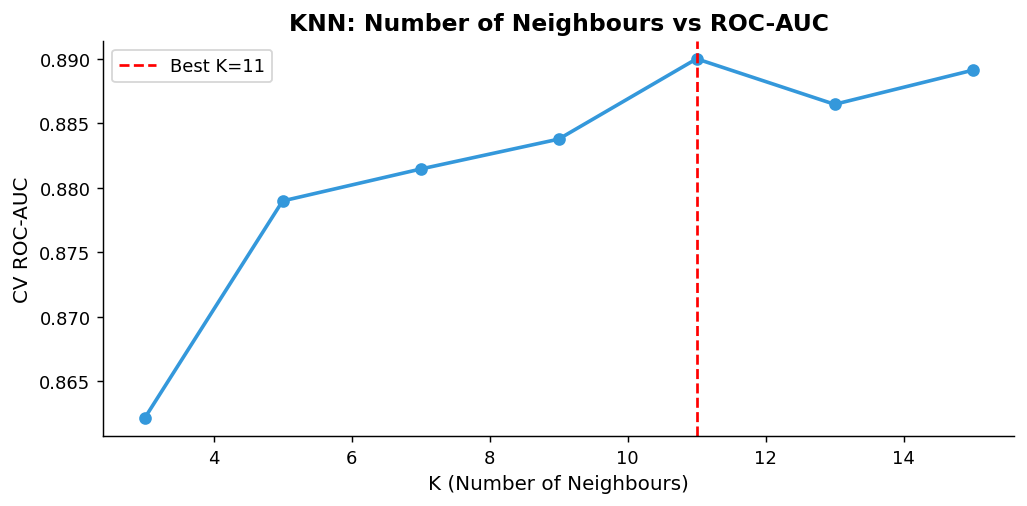

Saved to plots/knn_k_selection.png


In [5]:
# K vs AUC plot to visualise elbow
results = knn_grid.cv_results_
k_values = [p['n_neighbors'] for p in knn_grid.cv_results_['params']]
auc_means = knn_grid.cv_results_['mean_test_score']

# Group by k — take max AUC across metric/weight combos
k_auc = {}
for k, auc in zip(k_values, auc_means):
    k_auc[k] = max(k_auc.get(k, 0), auc)

k_sorted = sorted(k_auc.keys())
auc_sorted = [k_auc[k] for k in k_sorted]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_sorted, auc_sorted, marker='o', color='#3498db', linewidth=2)
ax.axvline(knn_grid.best_params_['n_neighbors'], color='red',
           linestyle='--', label=f"Best K={knn_grid.best_params_['n_neighbors']}")
ax.set_xlabel('K (Number of Neighbours)', fontsize=11)
ax.set_ylabel('CV ROC-AUC', fontsize=11)
ax.set_title('KNN: Number of Neighbours vs ROC-AUC', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/knn_k_selection.png")

## 6.4 Model 2 — Logistic Regression

Logistic Regression fits a linear decision boundary in the feature space. It is fast, interpretable via coefficients, and serves as a strong linear baseline.

In [6]:
# ─── Logistic Regression Hyperparameter Tuning ─────────────────────────────────
lr_param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1
)

print("Tuning Logistic Regression on Top-8 features...")
lr_grid.fit(X_train_top, y_train)

best_lr = lr_grid.best_estimator_
print(f"\nBest LR params : {lr_grid.best_params_}")
print(f"Best CV AUC    : {lr_grid.best_score_:.4f}")

# Also fit on full features
lr_full = LogisticRegression(**{k: v for k, v in lr_grid.best_params_.items()},
                             max_iter=1000, random_state=42)
lr_full.fit(X_train_full, y_train)

joblib.dump(best_lr, 'models/lr_top8.pkl')
joblib.dump(lr_full, 'models/lr_full.pkl')
print("\nLogistic Regression models saved.")

Tuning Logistic Regression on Top-8 features...

Best LR params : {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV AUC    : 0.8947

Logistic Regression models saved.


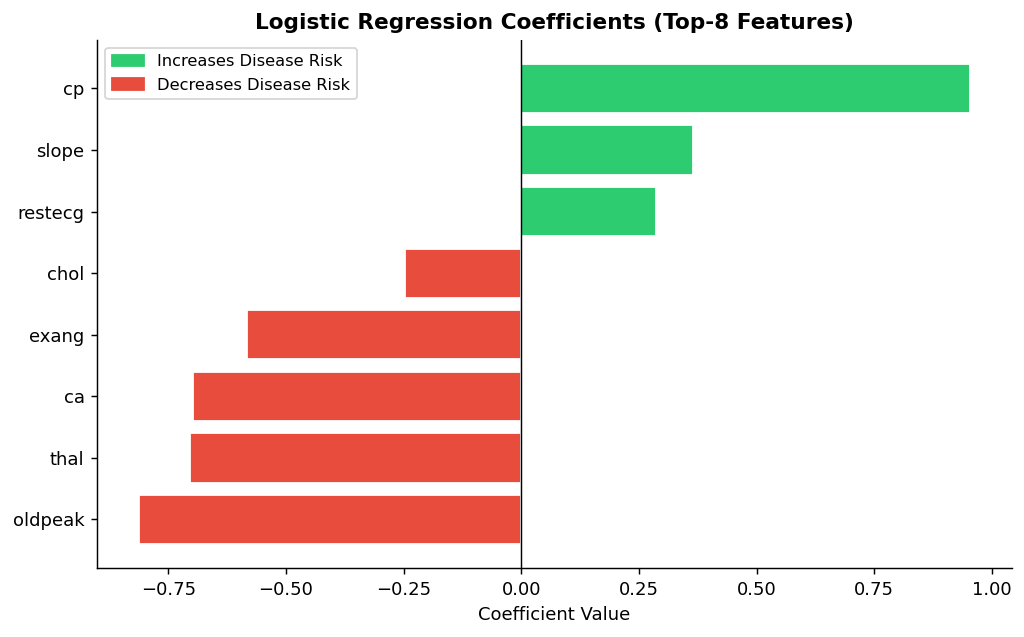

Saved to plots/lr_coefficients.png


In [7]:
# Plot feature coefficients (interpretability)
coef_df = pd.DataFrame({
    'Feature'    : top_features,
    'Coefficient': best_lr.coef_[0]
}).sort_values('Coefficient')

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (Top-8 Features)', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

pos_patch = mpatches.Patch(color='#2ecc71', label='Increases Disease Risk')
neg_patch = mpatches.Patch(color='#e74c3c', label='Decreases Disease Risk')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

plt.tight_layout()
plt.savefig('plots/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/lr_coefficients.png")

## 6.5 Model 3 — Gradient Boosting

Gradient Boosting builds an ensemble of weak decision trees sequentially, each correcting the errors of the previous. It is the most powerful model in our comparison but requires more careful hyperparameter tuning.

In [8]:
# ─── Gradient Boosting Hyperparameter Tuning ───────────────────────────────────
gb_param_grid = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    verbose=0
)

print("Tuning Gradient Boosting on Top-8 features... (may take ~1-2 min)")
gb_grid.fit(X_train_top, y_train)

best_gb = gb_grid.best_estimator_
print(f"\nBest GB params : {gb_grid.best_params_}")
print(f"Best CV AUC    : {gb_grid.best_score_:.4f}")

# Also fit on full features
gb_full = GradientBoostingClassifier(**gb_grid.best_params_, random_state=42)
gb_full.fit(X_train_full, y_train)

joblib.dump(best_gb, 'models/gb_top8.pkl')
joblib.dump(gb_full, 'models/gb_full.pkl')
print("\nGradient Boosting models saved.")

Tuning Gradient Boosting on Top-8 features... (may take ~1-2 min)

Best GB params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC    : 0.8816

Gradient Boosting models saved.


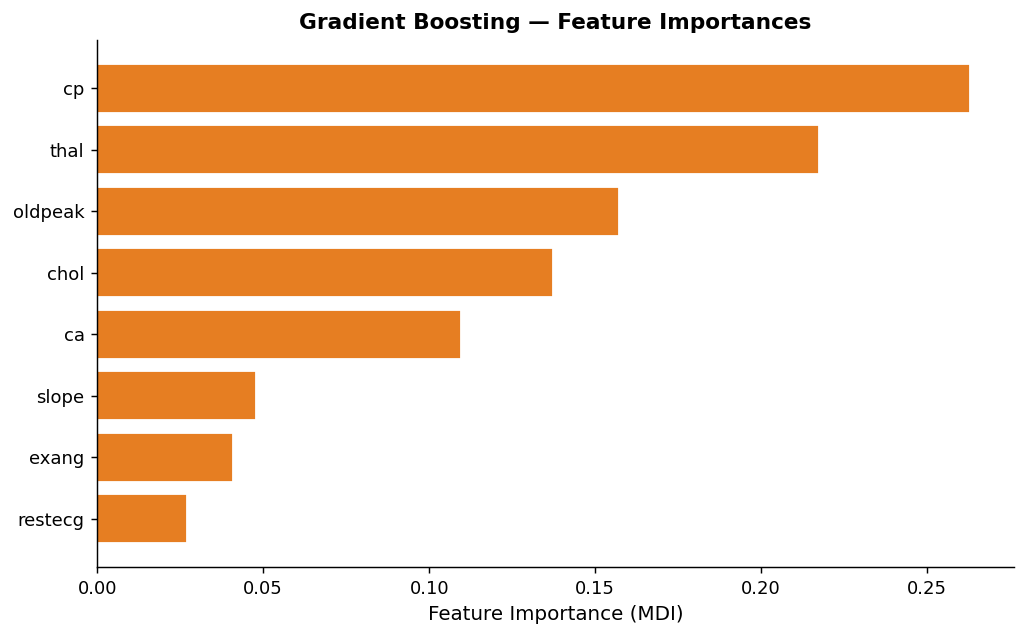

Saved to plots/gb_feature_importances.png


In [9]:
# GB feature importances
fi_df = pd.DataFrame({
    'Feature'   : top_features,
    'Importance': best_gb.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
        color='#e67e22', edgecolor='white')
ax.set_xlabel('Feature Importance (MDI)', fontsize=11)
ax.set_title('Gradient Boosting — Feature Importances', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plots/gb_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/gb_feature_importances.png")

## 6.6 Decision Boundary Visualisation (PCA 2D Projection)

Decision boundaries can only be plotted in 2D. We use **PCA** to project the Top-8 features into 2 principal components, then plot the boundary for each model.

> **Note:** The 2D projection loses some variance — the boundaries are approximations, not exact representations of the 8-D boundaries used for prediction.

PCA Explained Variance: PC1=28.3%  PC2=14.5%  Total=42.8%


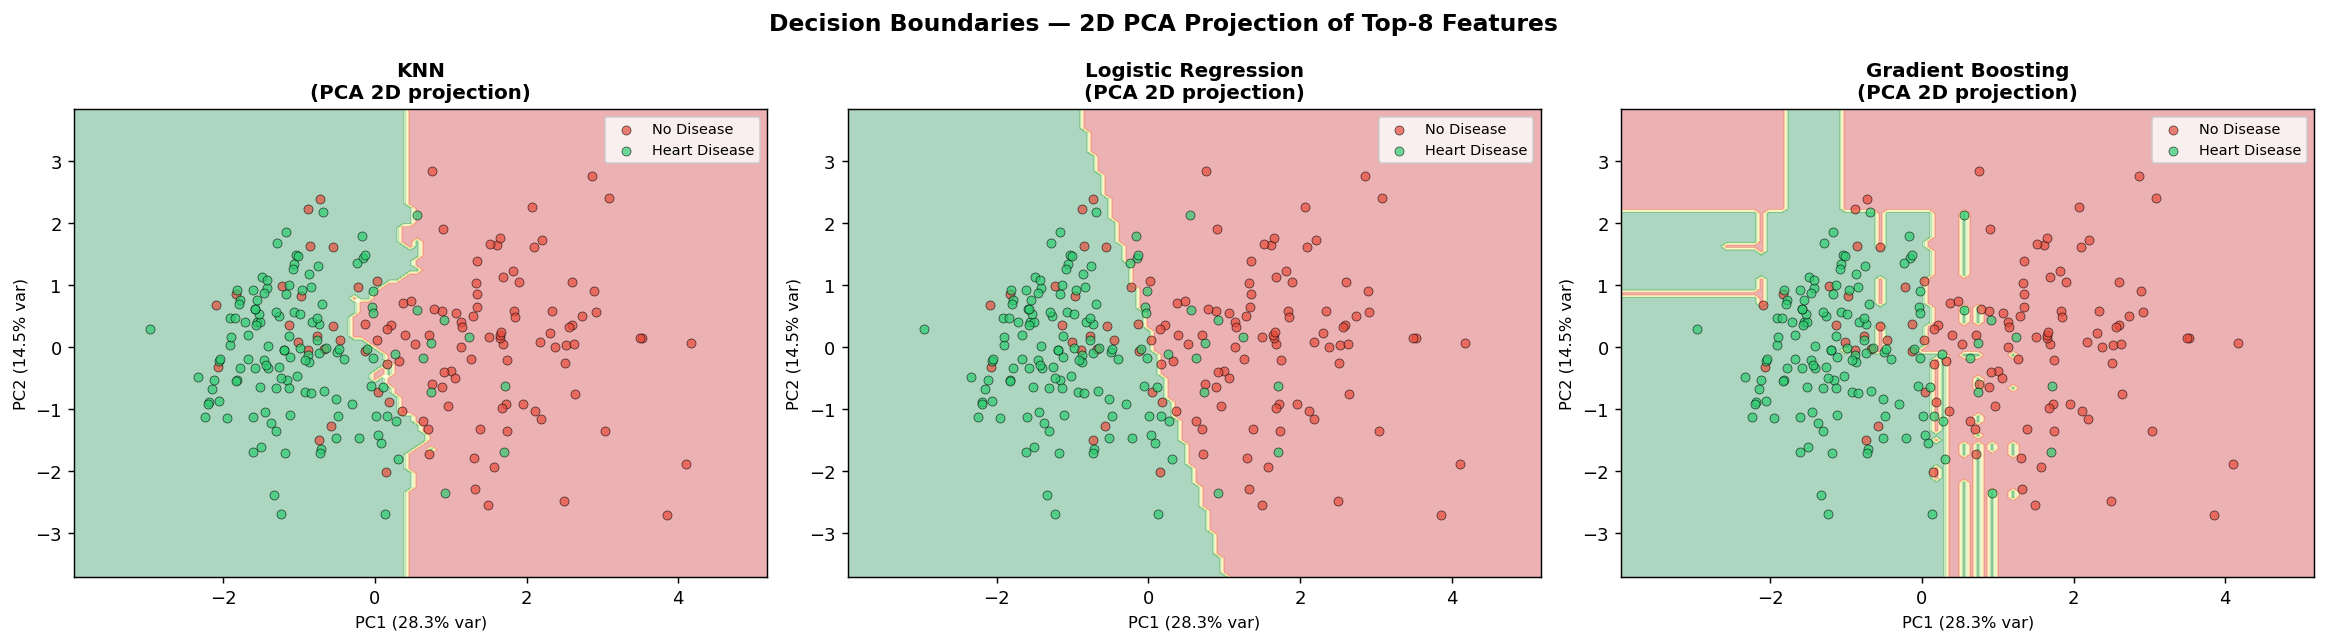

Saved to plots/decision_boundaries.png


In [10]:
# PCA projection
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_top)
X_test_pca  = pca.transform(X_test_top)

explained = pca.explained_variance_ratio_
print(f"PCA Explained Variance: PC1={explained[0]*100:.1f}%  PC2={explained[1]*100:.1f}%  "
      f"Total={sum(explained)*100:.1f}%")

# Train simple versions on PCA components for boundary plots only
models_2d = {
    'KNN'               : KNeighborsClassifier(**knn_grid.best_params_),
    'Logistic Regression': LogisticRegression(**{k: v for k, v in lr_grid.best_params_.items()},
                                              max_iter=1000, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(**gb_grid.best_params_, random_state=42)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models_2d.items()):
    model.fit(X_train_pca, y_train)

    disp = DecisionBoundaryDisplay.from_estimator(
        model, X_train_pca,
        response_method='predict',
        alpha=0.35,
        cmap=plt.cm.RdYlGn,
        ax=ax
    )

    # Scatter training points
    for cls, color, label in zip([0, 1], PALETTE, ['No Disease', 'Heart Disease']):
        mask = (y_train == cls).values
        ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                   c=color, edgecolor='k', linewidth=0.4,
                   s=25, alpha=0.7, label=label)

    ax.set_title(f'{name}\n(PCA 2D projection)', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)', fontsize=9)
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Decision Boundaries — 2D PCA Projection of Top-8 Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/decision_boundaries.png")

## 6.7 Stage 6 Summary

| Model | Best Params (Top-8) | CV AUC |
|---|---|---|
| KNN | See output above | See output above |
| Logistic Regression | See output above | See output above |
| Gradient Boosting | See output above | See output above |

All six models (3 models × 2 feature sets) are saved in `/models/` for evaluation in Stage 7.

---
**Next Stage →** `07_model_evaluation.ipynb`